# Laptop Price Prediction
### End-to-End EDA, Preprocessing, and Machine Learning

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plta

import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

## 2. Load Dataset

In [3]:
# Now loading the datasets here
df = pd.read_csv('laptop_data.csv')
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [44]:
df.columns

Index(['Company', 'TypeName', 'Inches', 'Ram', 'Weight', 'Price', 'X_res',
       'Y_res', 'PPI', 'IPS', 'Touchscreen', 'Cpu_Brand', 'Cpu_Speed',
       'Gpu_Brand', 'Memory_Type', 'Memory_GB', 'OS'],
      dtype='object')

In [45]:
df.shape()

TypeError: 'tuple' object is not callable

In [4]:
print("Shape:", df.shape)
print("Rows:", df.shape[0], "| Columns:", df.shape[1])

Shape: (1303, 12)
Rows: 1303 | Columns: 12


In [5]:
# Checking the type of the each columns
df.dtypes

Unnamed: 0            int64
Company              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price               float64
dtype: object

In [46]:
# Checking the null valuse inside our dataset 
df.isnull().sum()

Company        0
TypeName       0
Inches         0
Ram            0
Weight         0
Price          0
X_res          0
Y_res          0
PPI            0
IPS            0
Touchscreen    0
Cpu_Brand      0
Cpu_Speed      0
Gpu_Brand      0
Memory_Type    0
Memory_GB      0
OS             0
dtype: int64

In [7]:
# overall statistics of the dataset 
df.describe()

,Unnamed: 0,Inches,Price
count,1303.00000,1303.000000,1303.000000
mean,651.00000,15.017191,59870.042910
std,376.28801,1.426304,37243.201786
min,0.00000,10.100000,9270.720000
25%,325.50000,14.000000,31914.720000
50%,651.00000,15.600000,52054.560000
75%,976.50000,15.600000,79274.246400
max,1302.00000,18.400000,324954.720000


## 3. Data Cleaning

In [8]:
# Drop the unnamed index column
df.drop(columns=['Unnamed: 0'], inplace=True)
df.head(3)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000


In [9]:
# Clean Ram column - remove 'GB' and convert to int
df['Ram'] = df['Ram'].str.replace('GB', '').astype(int)
df['Ram'].value_counts()

Ram
8     619
4     375
16    200
6      41
12     25
2      22
32     17
24      3
64      1
Name: count, dtype: int64

In [10]:
# Clean Weight column - remove 'kg' and convert to float
df['Weight'] = df['Weight'].str.replace('kg', '').astype(float)
df['Weight'].describe()

count    1303.000000
mean        2.038734
std         0.665475
min         0.690000
25%         1.500000
50%         2.040000
75%         2.300000
max         4.700000
Name: Weight, dtype: float64

In [11]:
# Extract screen resolution width and height
df['X_res'] = df['ScreenResolution'].str.extract(r'(\d+)x\d+').astype(int)
df['Y_res'] = df['ScreenResolution'].str.extract(r'\d+x(\d+)').astype(int)
df[['ScreenResolution','X_res','Y_res']].head()

,ScreenResolution,X_res,Y_res
0,IPS Panel Retina Display 2560x1600,2560,1600
1,1440x900,1440,900
2,Full HD 1920x1080,1920,1080
3,IPS Panel Retina Display 2880x1800,2880,1800
4,IPS Panel Retina Display 2560x1600,2560,1600


In [12]:
# Calculate PPI (pixels per inch)
df['PPI'] = ((df['X_res']**2 + df['Y_res']**2)**0.5 / df['Inches']).round(2)
df['PPI'].describe()

count    1303.000000
mean      146.634589
std        43.121346
min        90.580000
25%       127.340000
50%       141.210000
75%       157.350000
max       352.470000
Name: PPI, dtype: float64

In [13]:
# Check if screen is IPS
df['IPS'] = df['ScreenResolution'].apply(lambda x: 1 if 'IPS' in x else 0)
df['IPS'].value_counts()

IPS
0    938
1    365
Name: count, dtype: int64

In [14]:
# Check if screen is Touchscreen
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x: 1 if 'Touch' in x else 0)
df['Touchscreen'].value_counts()

Touchscreen
0    1111
1     192
Name: count, dtype: int64

In [15]:
# Extract CPU brand
df['Cpu_Brand'] = df['Cpu'].apply(lambda x: x.split()[0])
df['Cpu_Brand'].value_counts()

Cpu_Brand
Intel      1240
AMD          62
Samsung       1
Name: count, dtype: int64

In [16]:
# Extract CPU speed - handles both 2GHz and 2.5GHz formats

df['Cpu_Speed'] = df['Cpu'].str.extract(r'(\d+\.?\d*)GHz').astype(float)
df['Cpu_Speed'].fillna(df['Cpu_Speed'].median(), inplace=True)
df['Cpu_Speed'].describe()

count    1303.000000
mean        2.298772
std         0.506340
min         0.900000
25%         2.000000
50%         2.500000
75%         2.700000
max         3.600000
Name: Cpu_Speed, dtype: float64

In [17]:
# Extract GPU brand
df['Gpu_Brand'] = df['Gpu'].apply(lambda x: x.split()[0])
df['Gpu_Brand'].value_counts()

Gpu_Brand
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64

In [18]:
# Classify memory type
def get_memory_type(mem):
    mem = str(mem).upper()
    if 'SSD' in mem and 'HDD' in mem:
        return 'Hybrid'
    elif 'SSD' in mem:
        return 'SSD'
    elif 'HDD' in mem:
        return 'HDD'
    elif 'FLASH' in mem or 'EMMC' in mem:
        return 'Flash'
    else:
        return 'Other'

df['Memory_Type'] = df['Memory'].apply(get_memory_type)
df['Memory_Type'].value_counts()

Memory_Type
SSD       643
HDD       376
Hybrid    200
Flash      74
Other      10
Name: count, dtype: int64

In [19]:
# Extract primary memory size in GB
def extract_memory_gb(mem):
    mem = str(mem)
    first = mem.split('+')[0].strip()
    if 'TB' in first:
        val = float(first.replace('TB','').strip().split()[0]) * 1000
    elif 'GB' in first:
        val = float(first.replace('GB','').strip().split()[0])
    else:
        val = 0
    return val

df['Memory_GB'] = df['Memory'].apply(extract_memory_gb)
df['Memory_GB'].value_counts()

Memory_GB
256.0     508
1000.0    250
128.0     177
512.0     140
500.0     132
32.0       45
64.0       17
2000.0     16
16.0       10
180.0       5
240.0       1
8.0         1
508.0       1
Name: count, dtype: int64

In [20]:
# Simplify OpSys
def simplify_os(os):
    if 'Windows' in str(os):
        return 'Windows'
    elif 'Mac' in str(os) or 'macOS' in str(os):
        return 'Mac'
    elif 'Linux' in str(os):
        return 'Linux'
    elif 'Chrome' in str(os):
        return 'Chrome OS'
    elif 'No OS' in str(os):
        return 'No OS'
    else:
        return 'Other'

df['OS'] = df['OpSys'].apply(simplify_os)
df['OS'].value_counts()

OS
Windows      1125
No OS          66
Linux          62
Chrome OS      27
Mac            21
Other           2
Name: count, dtype: int64

In [21]:
# Drop original raw columns now that features are extracted
df.drop(columns=['ScreenResolution','Cpu','Gpu','Memory','OpSys'], inplace=True)
df.head(3)

,Company,TypeName,Inches,Ram,Weight,Price,X_res,Y_res,PPI,IPS,Touchscreen,Cpu_Brand,Cpu_Speed,Gpu_Brand,Memory_Type,Memory_GB,OS
0,Apple,Ultrabook,13.3,8,1.37,71378.6832,2560,1600,226.98,1,0,Intel,2.3,Intel,SSD,128.0,Mac
1,Apple,Ultrabook,13.3,8,1.34,47895.5232,1440,900,127.68,0,0,Intel,1.8,Intel,Flash,128.0,Mac
2,HP,Notebook,15.6,8,1.86,30636.0000,1920,1080,141.21,0,0,Intel,2.5,Intel,SSD,256.0,No OS


In [22]:
print("Final cleaned shape:", df.shape)
df.dtypes

Final cleaned shape: (1303, 17)


Company         object
TypeName        object
Inches         float64
Ram              int64
Weight         float64
Price          float64
X_res            int64
Y_res            int64
PPI            float64
IPS              int64
Touchscreen      int64
Cpu_Brand       object
Cpu_Speed      float64
Gpu_Brand       object
Memory_Type     object
Memory_GB      float64
OS              object
dtype: object

## 4. Exploratory Data Analysis

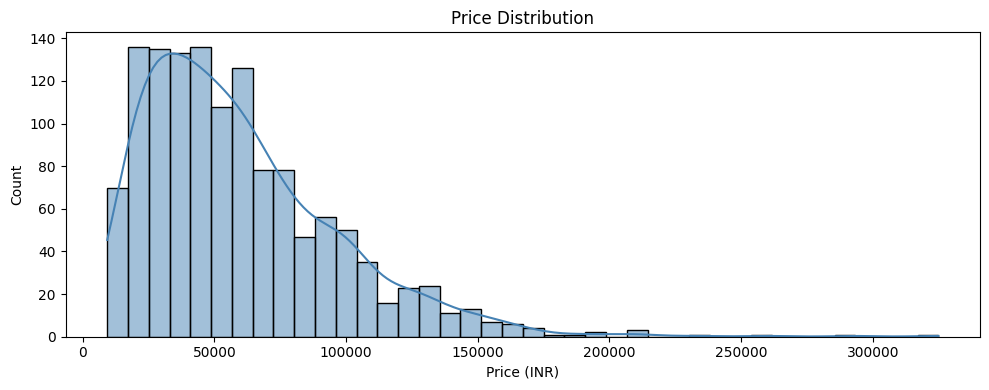

In [23]:
# Price distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['Price'], kde=True, bins=40, color='steelblue')
plt.title('Price Distribution')
plt.xlabel('Price (INR)')
plt.tight_layout()
plt.show()

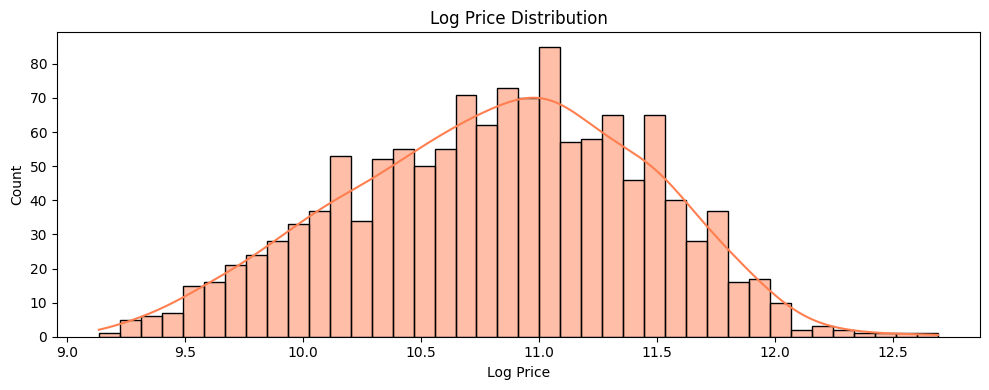

In [24]:
# Log price distribution
plt.figure(figsize=(10, 4))
sns.histplot(np.log(df['Price']), kde=True, bins=40, color='coral')
plt.title('Log Price Distribution')
plt.xlabel('Log Price')
plt.tight_layout()
plt.show()

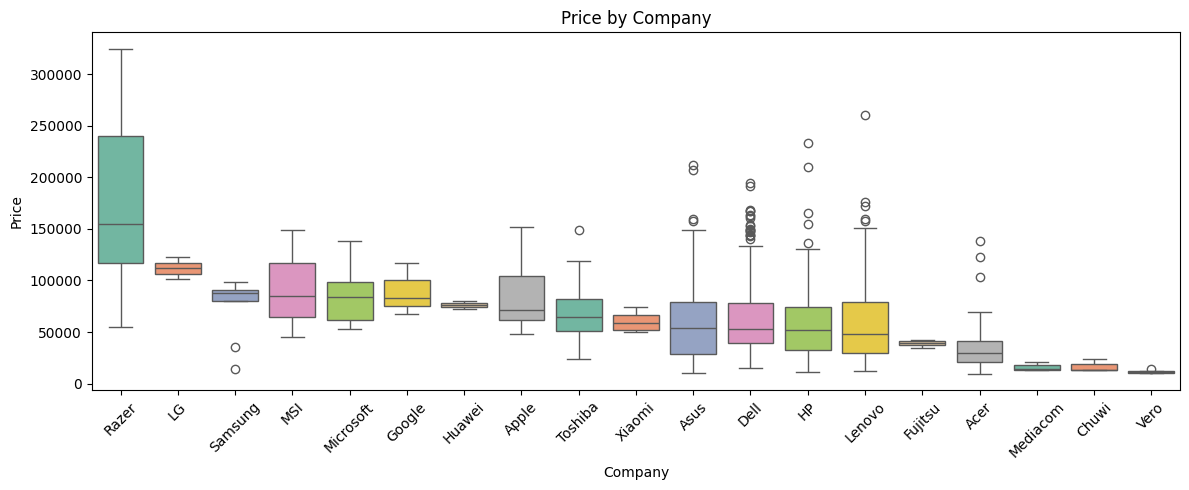

In [25]:
# Price by Company
plt.figure(figsize=(12, 5))
order = df.groupby('Company')['Price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Company', y='Price', order=order, palette='Set2')
plt.xticks(rotation=45)
plt.title('Price by Company')
plt.tight_layout()
plt.show()

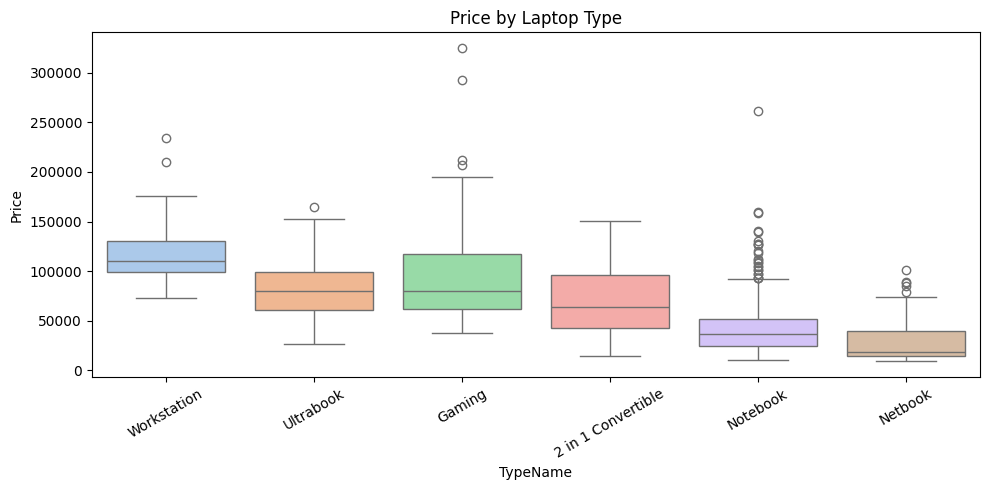

In [26]:
# Price by Laptop Type
plt.figure(figsize=(10, 5))
order = df.groupby('TypeName')['Price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='TypeName', y='Price', order=order, palette='pastel')
plt.title('Price by Laptop Type')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

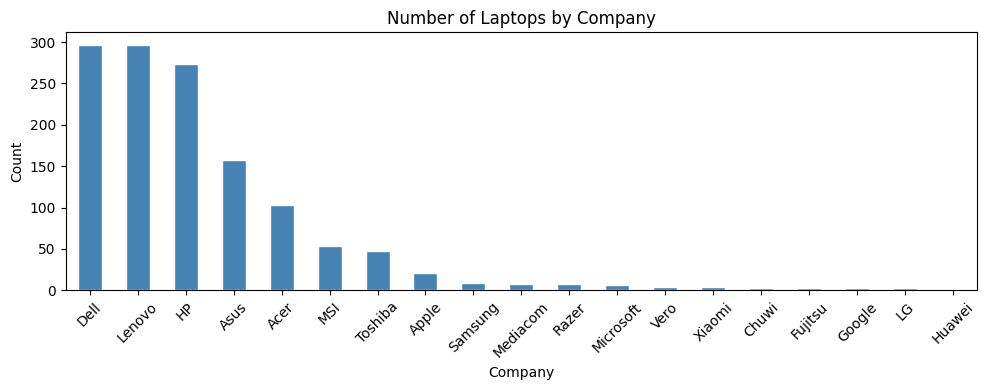

In [27]:
# Count of laptops by Company
plt.figure(figsize=(10, 4))
df['Company'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Number of Laptops by Company')
plt.xlabel('Company')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

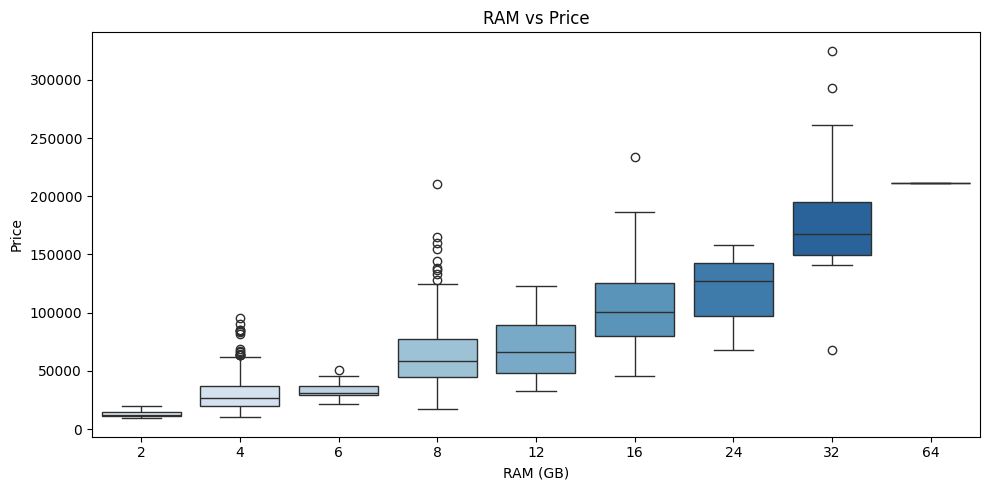

In [28]:
# RAM vs Price
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Ram', y='Price', palette='Blues')
plt.title('RAM vs Price')
plt.xlabel('RAM (GB)')
plt.tight_layout()
plt.show()

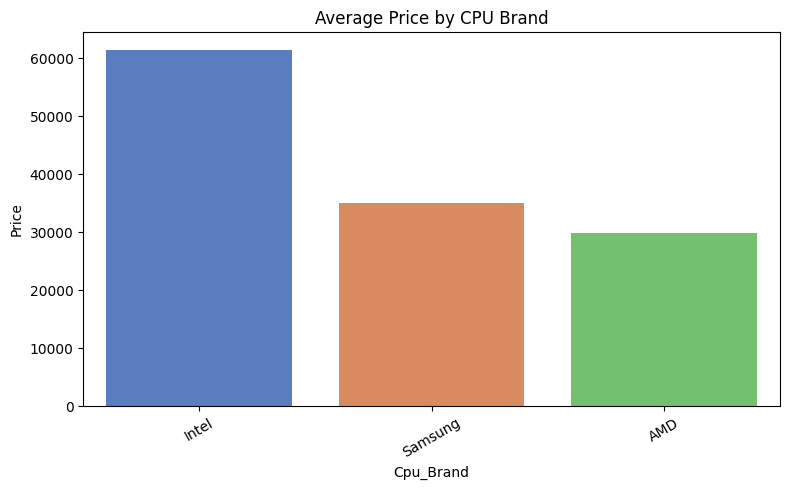

In [29]:
# CPU Brand vs Price
plt.figure(figsize=(8, 5))
order = df.groupby('Cpu_Brand')['Price'].median().sort_values(ascending=False).index
sns.barplot(data=df, x='Cpu_Brand', y='Price', order=order, palette='muted', ci=None)
plt.title('Average Price by CPU Brand')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

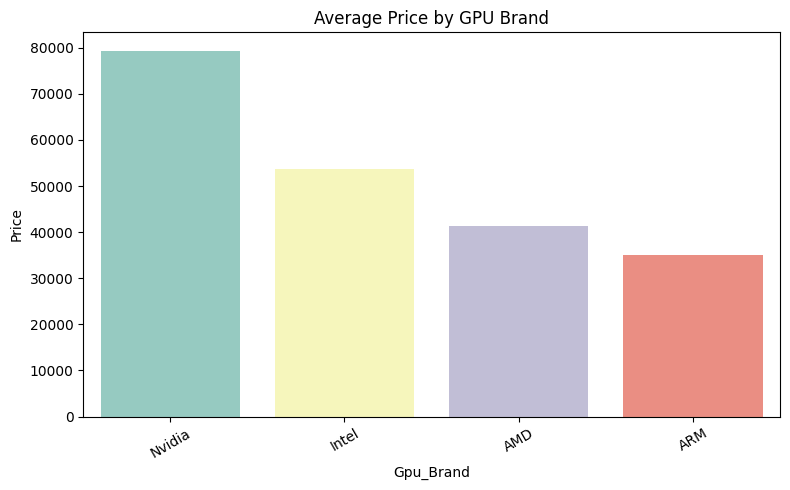

In [30]:
# GPU Brand vs Price
plt.figure(figsize=(8, 5))
order = df.groupby('Gpu_Brand')['Price'].median().sort_values(ascending=False).index
sns.barplot(data=df, x='Gpu_Brand', y='Price', order=order, palette='Set3', ci=None)
plt.title('Average Price by GPU Brand')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

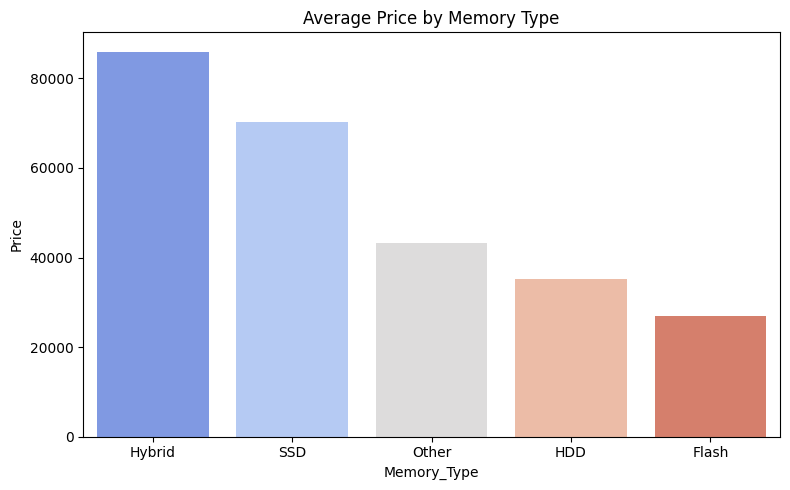

In [31]:
# Memory type vs Price
plt.figure(figsize=(8, 5))
order = df.groupby('Memory_Type')['Price'].median().sort_values(ascending=False).index
sns.barplot(data=df, x='Memory_Type', y='Price', order=order, palette='coolwarm', ci=None)
plt.title('Average Price by Memory Type')
plt.tight_layout()
plt.show()

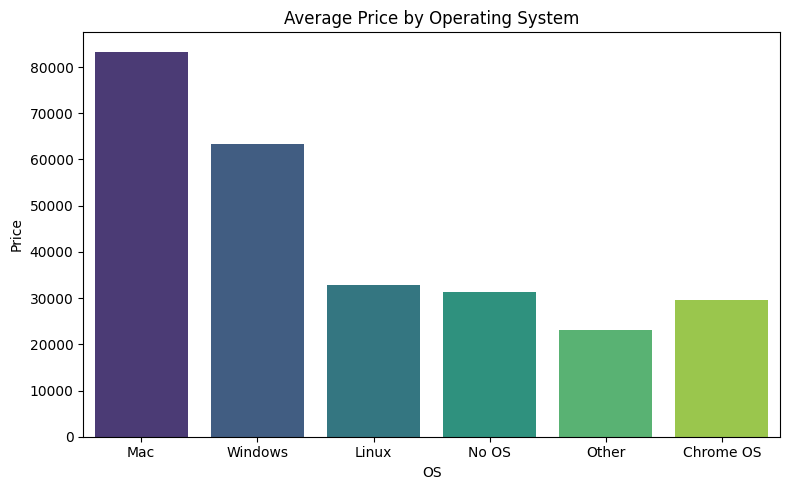

In [32]:
# OS vs Price
plt.figure(figsize=(8, 5))
order = df.groupby('OS')['Price'].median().sort_values(ascending=False).index
sns.barplot(data=df, x='OS', y='Price', order=order, palette='viridis', ci=None)
plt.title('Average Price by Operating System')
plt.tight_layout()
plt.show()

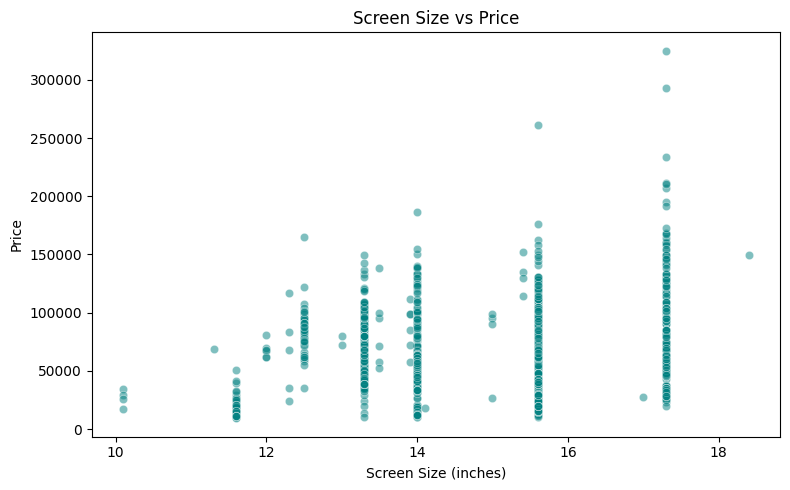

In [33]:
# Screen size vs Price scatter
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Inches', y='Price', alpha=0.5, color='teal')
plt.title('Screen Size vs Price')
plt.xlabel('Screen Size (inches)')
plt.tight_layout()
plt.show()

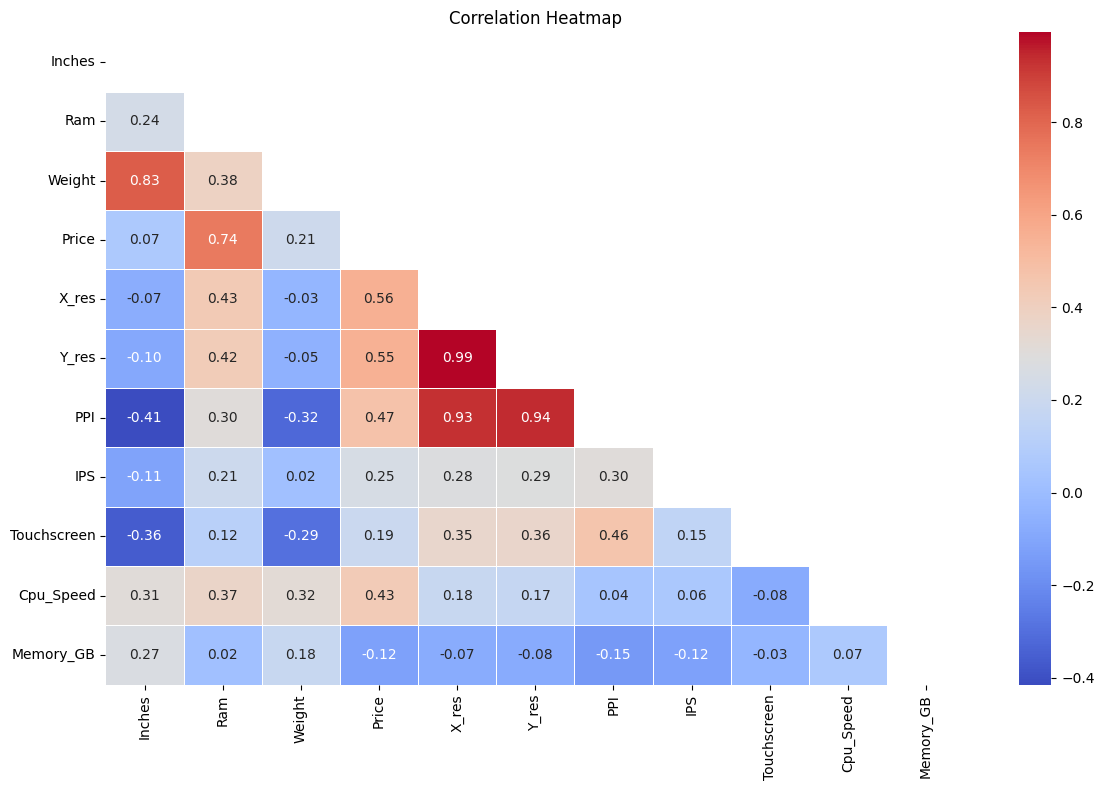

In [34]:
# Correlation heatmap
num_cols = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(12, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

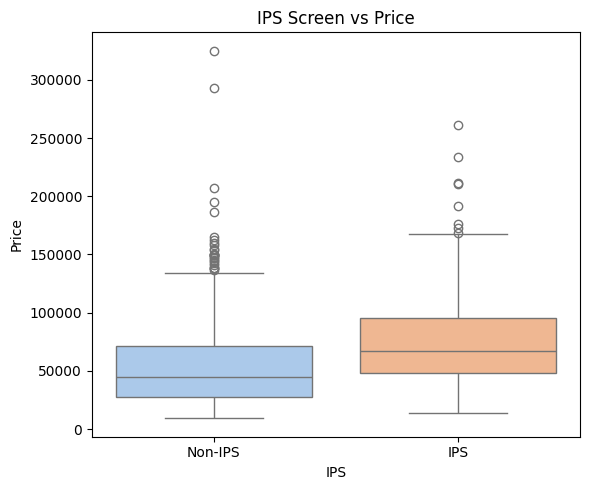

In [35]:
# IPS screen effect on price
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='IPS', y='Price', palette='pastel')
plt.xticks([0,1], ['Non-IPS','IPS'])
plt.title('IPS Screen vs Price')
plt.tight_layout()
plt.show()

## 5. Feature Engineering and Encoding

In [36]:
# Prepare features
df_model = df.copy()

# One-hot encode categorical columns
cat_cols = ['Company', 'TypeName', 'Cpu_Brand', 'Gpu_Brand', 'Memory_Type', 'OS']
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print("Shape after encoding:", df_model.shape)
df_model.head(2)

Shape after encoding: (1303, 48)


,Inches,Ram,Weight,Price,X_res,Y_res,PPI,IPS,Touchscreen,Cpu_Speed,...,Gpu_Brand_Nvidia,Memory_Type_HDD,Memory_Type_Hybrid,Memory_Type_Other,Memory_Type_SSD,OS_Linux,OS_Mac,OS_No OS,OS_Other,OS_Windows
0,13.3,8,1.37,71378.6832,2560,1600,226.98,1,0,2.3,...,False,False,False,False,True,False,True,False,False,False
1,13.3,8,1.34,47895.5232,1440,900,127.68,0,0,1.8,...,False,False,False,False,False,False,True,False,False,False


In [37]:
# Use log price as target for better model performance
X = df_model.drop(columns=['Price'])
y = np.log(df_model['Price'])

print("Features:", X.shape[1])
print("Target samples:", y.shape[0])

Features: 47
Target samples: 1303


In [38]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 1042
Test size: 261


## 6. Model Training and Evaluation

In [39]:
# Train multiple models and compare
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(np.exp(y_test), np.exp(preds))
    r2  = r2_score(y_test, preds)
    results[name] = {'MAE': round(mae, 2), 'R2': round(r2, 4)}

results_df = pd.DataFrame(results).T
results_df

,MAE,R2
Linear Regression,12656.29,0.8112
Ridge,12604.96,0.8097
Random Forest,10071.78,0.8664
Gradient Boosting,10415.98,0.8608


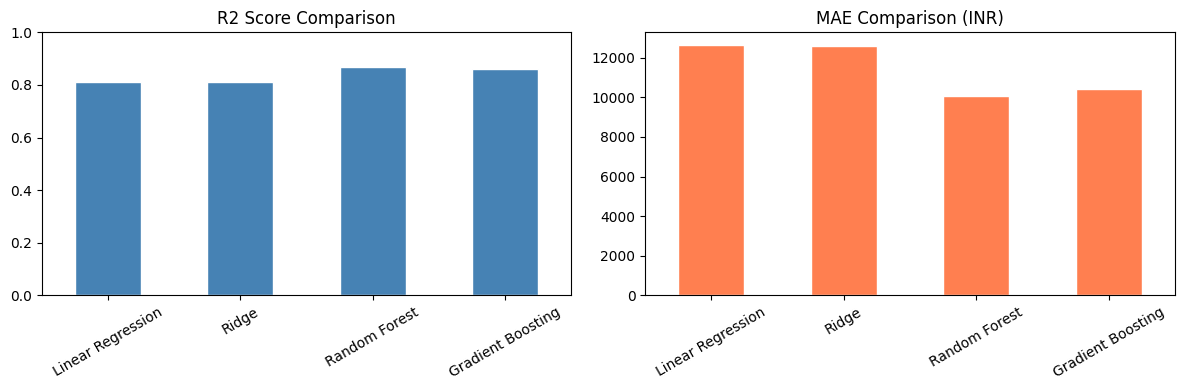

In [40]:
# Plot model comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results_df['R2'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('R2 Score Comparison')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=30)

results_df['MAE'].plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('MAE Comparison (INR)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

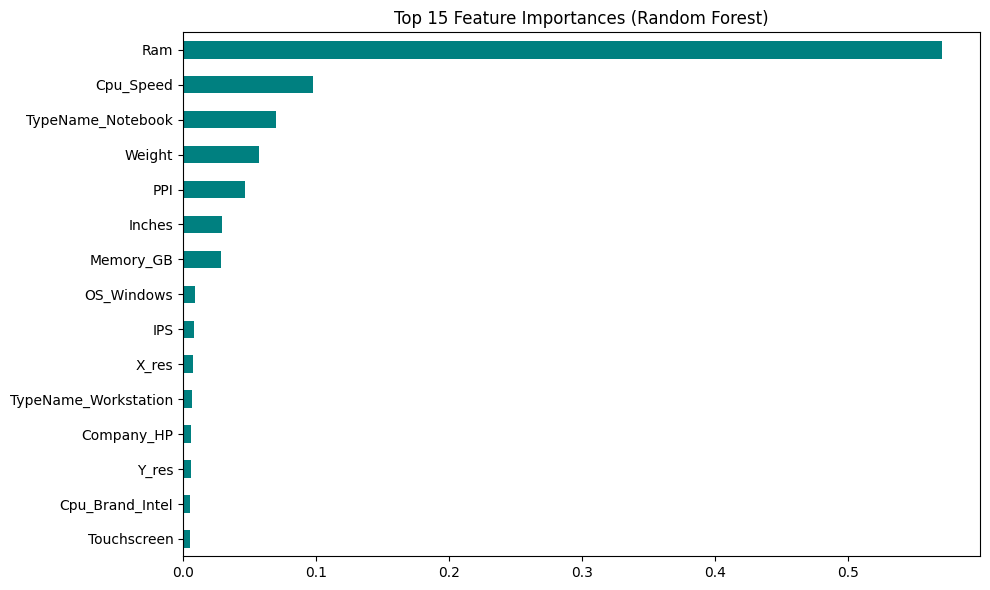

In [41]:
# Best model: Random Forest - feature importance
rf_model = models['Random Forest']
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
top15 = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top15.sort_values().plot(kind='barh', color='teal')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

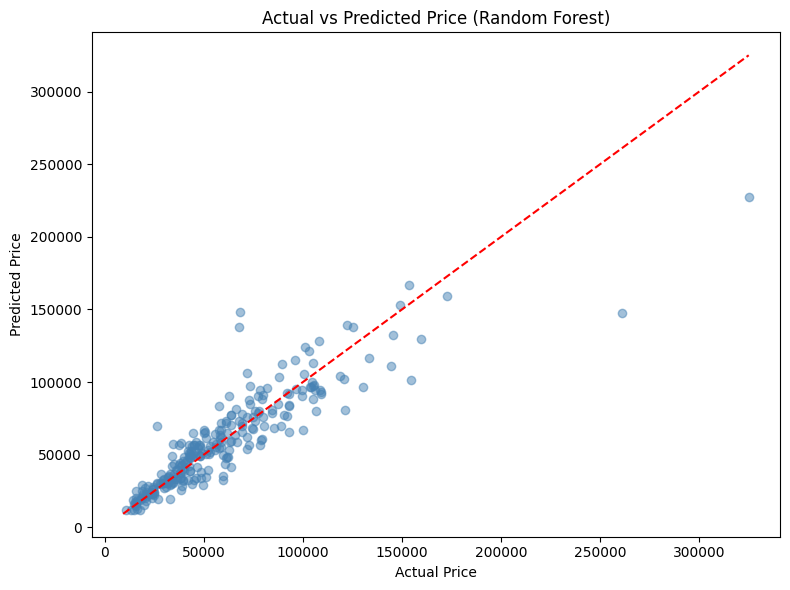

In [42]:
# Actual vs Predicted plot
best_model = models['Random Forest']
preds = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(np.exp(y_test), np.exp(preds), alpha=0.5, color='steelblue')
plt.plot([df['Price'].min(), df['Price'].max()],
         [df['Price'].min(), df['Price'].max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price (Random Forest)')
plt.tight_layout()
plt.show()

In [43]:
# Save model and feature columns for Streamlit app
import pickle

with open('laptop_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("Model saved as laptop_model.pkl")
print("Feature columns saved as feature_columns.pkl")
print("R2 Score:", round(r2_score(y_test, preds), 4))
print("MAE (INR):", round(mean_absolute_error(np.exp(y_test), np.exp(preds)), 2))

Model saved as laptop_model.pkl
Feature columns saved as feature_columns.pkl
R2 Score: 0.8664
MAE (INR): 10071.78
